In [1]:
import pandas as pd

In [2]:


data = pd.read_csv('data/RNA-Seq-expression-Norilsk2019.csv')

In [3]:
data

,Gene,Species,log_2 fold change,Adjusted p-value
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84
...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71


c:\python_env\biologia_computacional\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


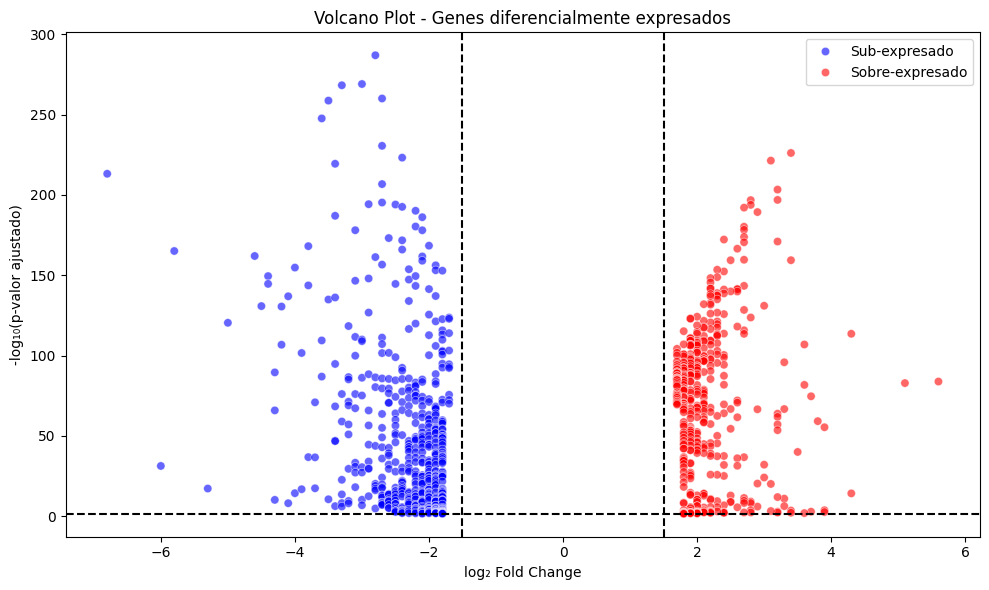

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asumiendo que tu DataFrame se llama "data"
df = data.copy()

# Umbrales definidos
fc_threshold = 1.5  # Cambio de al menos 2^(1.5) ≈ 2.8 veces
pval_threshold = 0.05

# Clasificación
df['Significativo'] = 'No significativo'
df.loc[(df['log_2 fold change'] >= fc_threshold) & (df['Adjusted p-value'] < pval_threshold), 'Significativo'] = 'Sobre-expresado'
df.loc[(df['log_2 fold change'] <= -fc_threshold) & (df['Adjusted p-value'] < pval_threshold), 'Significativo'] = 'Sub-expresado'

# Volcano plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='log_2 fold change',
    y=-np.log10(df['Adjusted p-value']),
    hue='Significativo',
    palette={'Sobre-expresado': 'red', 'Sub-expresado': 'blue', 'No significativo': 'gray'},
    alpha=0.6
)
plt.axhline(-np.log10(pval_threshold), ls='--', color='black')
plt.axvline(fc_threshold, ls='--', color='black')
plt.axvline(-fc_threshold, ls='--', color='black')
plt.xlabel('log₂ Fold Change')
plt.ylabel('-log₁₀(p-valor ajustado)')
plt.title('Volcano Plot - Genes diferencialmente expresados')
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
import mygene

mg = mygene.MyGeneInfo()

# Filtrar genes sobre-expresados
genes_up = df[(df['log_2 fold change'] >= fc_threshold) & (df['Adjusted p-value'] < pval_threshold)]
gene_ids = genes_up['Gene'].tolist()

# Consulta a MyGene
results = mg.querymany(gene_ids, scopes='ensembl.gene', fields='symbol,name,go', species='human')

# Convertir a DataFrame
go_df = pd.DataFrame(results)

# Filtrar y mostrar columnas relevantes
go_df = go_df[['query', 'symbol', 'name', 'go']]
go_df.head()


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
8 input query terms found dup hits:	[('ENSG00000137959', 5), ('ENSG00000165949', 4), ('ENSG00000137965', 4), ('ENSG00000187608', 2), ('E


,query,symbol,name,go
0,ENSG00000177606,JUN,"Jun proto-oncogene, AP-1 transcription factor ...","{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'..."
1,ENSG00000164309,CMYA5,cardiomyopathy associated 5,"{'CC': [{'evidence': 'IEA', 'gocategory': 'CC'..."
2,ENSG00000184545,DUSP8,dual specificity phosphatase 8,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
3,ENSG00000085465,OVGP1,oviductal glycoprotein 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
4,ENSG00000087589,CASS4,Cas scaffold protein family member 4,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."


In [19]:
go_df

,query,symbol,name,go
0,ENSG00000177606,JUN,"Jun proto-oncogene, AP-1 transcription factor ...","{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'..."
1,ENSG00000164309,CMYA5,cardiomyopathy associated 5,"{'CC': [{'evidence': 'IEA', 'gocategory': 'CC'..."
2,ENSG00000184545,DUSP8,dual specificity phosphatase 8,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
3,ENSG00000085465,OVGP1,oviductal glycoprotein 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
4,ENSG00000087589,CASS4,Cas scaffold protein family member 4,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
...,...,...,...,...
442,ENSG00000278053,DDX52,DExD-box helicase 52,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
443,ENSG00000137221,TJAP1,tight junction associated protein 1,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
444,ENSG00000092020,PPP2R3C,protein phosphatase 2 regulatory subunit B''gamma,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
445,ENSG00000089195,TRMT6,tRNA methyltransferase 6 non-catalytic subunit,"{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'..."


In [17]:
go_df['go'][0]

{'BP': [{'evidence': 'IDA',
   'gocategory': 'BP',
   'id': 'GO:0000122',
   'pubmed': 2833704,
   'qualifier': 'involved_in',
   'term': 'negative regulation of transcription by RNA polymerase II'},
  {'evidence': 'IMP',
   'gocategory': 'BP',
   'id': 'GO:0000122',
   'pubmed': 21113145,
   'qualifier': 'involved_in',
   'term': 'negative regulation of transcription by RNA polymerase II'},
  {'evidence': 'IEA',
   'gocategory': 'BP',
   'id': 'GO:0001525',
   'qualifier': 'acts_upstream_of_or_within',
   'term': 'angiogenesis'},
  {'evidence': 'IEA',
   'gocategory': 'BP',
   'id': 'GO:0001774',
   'qualifier': 'acts_upstream_of_or_within',
   'term': 'microglial cell activation'},
  {'evidence': 'IEA',
   'gocategory': 'BP',
   'id': 'GO:0001889',
   'qualifier': 'acts_upstream_of_or_within',
   'term': 'liver development'},
  {'evidence': 'IEA',
   'gocategory': 'BP',
   'id': 'GO:0001938',
   'qualifier': 'acts_upstream_of_or_within',
   'term': 'positive regulation of endothelial

In [12]:
import pandas as pd
import ast

# Asegurarse que la columna 'go' es un diccionario
go_df['go'] = go_df['go'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

bp_terms = []

for _, row in go_df.iterrows():
    go_data = row['go']
    if isinstance(go_data, dict) and 'BP' in go_data:
        for bp in go_data['BP']:
            # Solo agregar si es dict y tiene la clave 'term'
            if isinstance(bp, dict) and 'term' in bp:
                bp_terms.append({
                    'Gene': row['symbol'],
                    'GO_term': bp.get('term'),
                    'Evidence': bp.get('evidence')
                })

bp_df = pd.DataFrame(bp_terms)
print(bp_df.head())


  Gene                                            GO_term Evidence
0  JUN  negative regulation of transcription by RNA po...      IDA
1  JUN  negative regulation of transcription by RNA po...      IMP
2  JUN                                       angiogenesis      IEA
3  JUN                         microglial cell activation      IEA
4  JUN                                  liver development      IEA


In [29]:
bp_df

,Gene,GO_term,Evidence
0,JUN,negative regulation of transcription by RNA po...,IDA
1,JUN,negative regulation of transcription by RNA po...,IMP
2,JUN,angiogenesis,IEA
3,JUN,microglial cell activation,IEA
4,JUN,liver development,IEA
...,...,...,...
5258,TMEM70,mitochondrial proton-transporting ATP synthase...,IBA
5259,TMEM70,mitochondrial proton-transporting ATP synthase...,IMP
5260,TMEM70,mitochondrial proton-transporting ATP synthase...,ISS
5261,TMEM70,protein complex oligomerization,IDA


In [15]:
bp_df['GO_term'][0]

'negative regulation of transcription by RNA polymerase II'

In [20]:
top_terms = bp_df['GO_term'].value_counts().head(10)
print(top_terms)


GO_term
positive regulation of transcription by RNA polymerase II    97
regulation of transcription by RNA polymerase II             78
negative regulation of transcription by RNA polymerase II    70
regulation of DNA-templated transcription                    64
positive regulation of DNA-templated transcription           48
defense response to virus                                    47
innate immune response                                       42
negative regulation of DNA-templated transcription           40
apoptotic process                                            39
DNA damage response                                          34
Name: count, dtype: int64


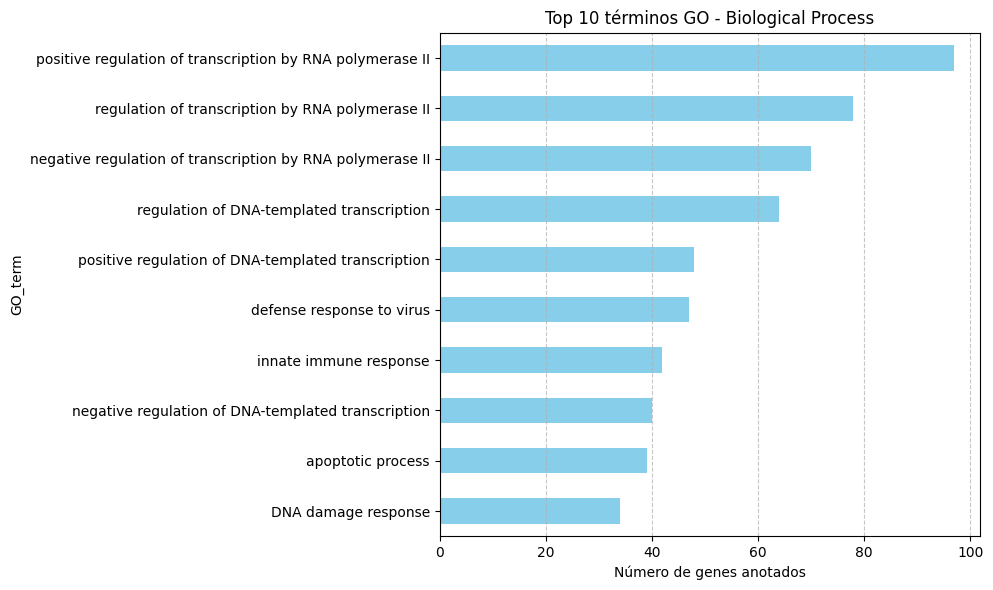

In [28]:
import matplotlib.pyplot as plt

# Ejemplo con conteos de términos GO (puede venir de tu dataframe)
go_counts = bp_df['GO_term'].value_counts().head(10)

plt.figure(figsize=(10,6))
go_counts.sort_values().plot(kind='barh', color='skyblue')
plt.xlabel('Número de genes anotados')
plt.title('Top 10 términos GO - Biological Process')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


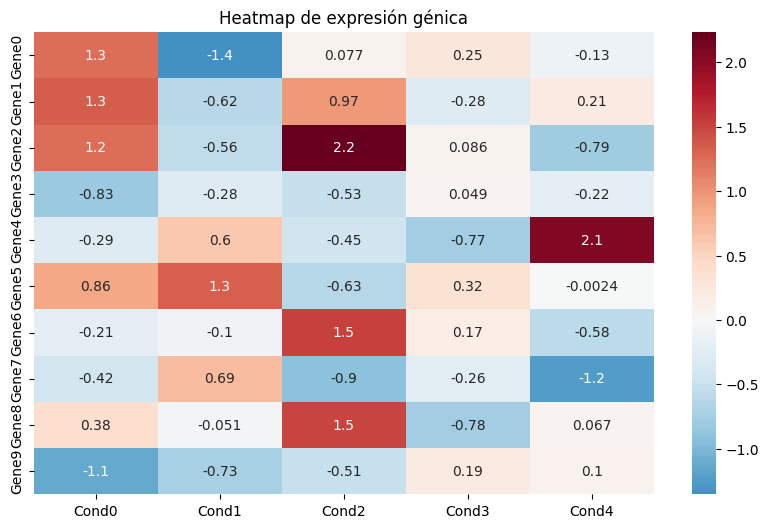

In [17]:
# df_exp = dataframe con expresión (genes filas, condiciones columnas)
# Ejemplo ficticio:
import numpy as np
import seaborn as sns

# Data de ejemplo
df_exp = pd.DataFrame(np.random.randn(10, 5), 
                      index=['Gene'+str(i) for i in range(10)], 
                      columns=['Cond'+str(i) for i in range(5)])

plt.figure(figsize=(10, 6))
sns.heatmap(df_exp, cmap='RdBu_r', center=0, annot=True)
plt.title('Heatmap de expresión génica')
plt.show()


# PLOTS

In [24]:
data

,Gene,Species,log_2 fold change,Adjusted p-value
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84
...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71


In [24]:
import pandas as pd
import ast

# Asegurarse que la columna 'go' es un diccionario
go_df['go'] = go_df['go'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

bp_terms = []

for _, row in go_df.iterrows():
    go_data = row['go']
    if isinstance(go_data, dict) and 'BP' in go_data:
        for bp in go_data['BP']:
            # Solo agregar si es dict y tiene la clave 'term'
            if isinstance(bp, dict) and 'term' in bp:
                bp_terms.append({
                    'Gene': row['symbol'],
                    'GO_term': bp.get('term'),
                    'Evidence': bp.get('evidence')
                })

bp_df = pd.DataFrame(bp_terms)
print(bp_df.head())


  Gene                                            GO_term Evidence
0  JUN  negative regulation of transcription by RNA po...      IDA
1  JUN  negative regulation of transcription by RNA po...      IMP
2  JUN                                       angiogenesis      IEA
3  JUN                         microglial cell activation      IEA
4  JUN                                  liver development      IEA


In [25]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
res = gp.profile(organism='hsapiens', query=data['Gene'].tolist())

In [26]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

# Lista de genes significativos
sig_genes = data.loc[data['Adjusted p-value'] < 0.05, 'Gene'].tolist()

# Enriquecimiento GO y otros
results = gp.profile(organism='hsapiens', query=sig_genes)

# Mostrar top resultados
print(results[['native','name','p_value','term_size','query_size','intersection_size']].head())


       native                               name       p_value  term_size  \
0  GO:0005737                          cytoplasm  2.874255e-23      12527   
1  GO:0005515                    protein binding  1.481642e-18      15123   
2  GO:0005654                        nucleoplasm  1.582584e-15       4255   
3   TF:M00333  Factor: ZF5; motif: NRNGNGCGCGCWN  2.058693e-14      15500   
4  GO:0043226                          organelle  8.319142e-14      16936   

   query_size  intersection_size  
0         860                632  
1         852                746  
2         860                269  
3         878                775  
4         860                751  


In [31]:
results

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:CC,GO:0005737,cytoplasm,2.874255e-23,True,"""The contents of a cell excluding the plasma m...",12527,860,632,22149,0.734884,0.050451,query_1,"[GO:0005622, GO:0110165]"
1,GO:MF,GO:0005515,protein binding,1.481642e-18,True,"""Binding to a protein."" [GOC:go_curators]",15123,852,746,20246,0.875587,0.049329,query_1,[GO:0005488]
2,GO:CC,GO:0005654,nucleoplasm,1.582584e-15,True,"""That part of the nuclear content other than t...",4255,860,269,22149,0.312791,0.063220,query_1,"[GO:0031981, GO:0110165]"
3,TF,TF:M00333,Factor: ZF5; motif: NRNGNGCGCGCWN,2.058693e-14,True,Factor: ZF5; motif: NRNGNGCGCGCWN,15500,878,775,20092,0.882688,0.050000,query_1,[TF:M00000]
4,GO:CC,GO:0043226,organelle,8.319142e-14,True,"""Organized structure of distinctive morphology...",16936,860,751,22149,0.873256,0.044343,query_1,[GO:0110165]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,GO:BP,GO:0005996,monosaccharide metabolic process,4.797238e-02,True,"""The chemical reactions and pathways involving...",250,831,25,21026,0.030084,0.100000,query_1,"[GO:0005975, GO:0044281]"
572,GO:CC,GO:0005774,vacuolar membrane,4.839375e-02,True,"""The lipid bilayer surrounding the vacuole and...",498,860,37,22149,0.043023,0.074297,query_1,"[GO:0005773, GO:0098588]"
573,TF,TF:M02065,Factor: ER81; motif: RCCGGAARYN,4.867476e-02,True,Factor: ER81; motif: RCCGGAARYN,13100,878,630,20092,0.717540,0.048092,query_1,[TF:M00000]
574,GO:MF,GO:0106423,tubulin-tyrosine carboxypeptidase,4.951576e-02,True,"""Catalysis of the reaction: C-terminal L-alpha...",3,852,3,20246,0.003521,1.000000,query_1,[GO:0004181]


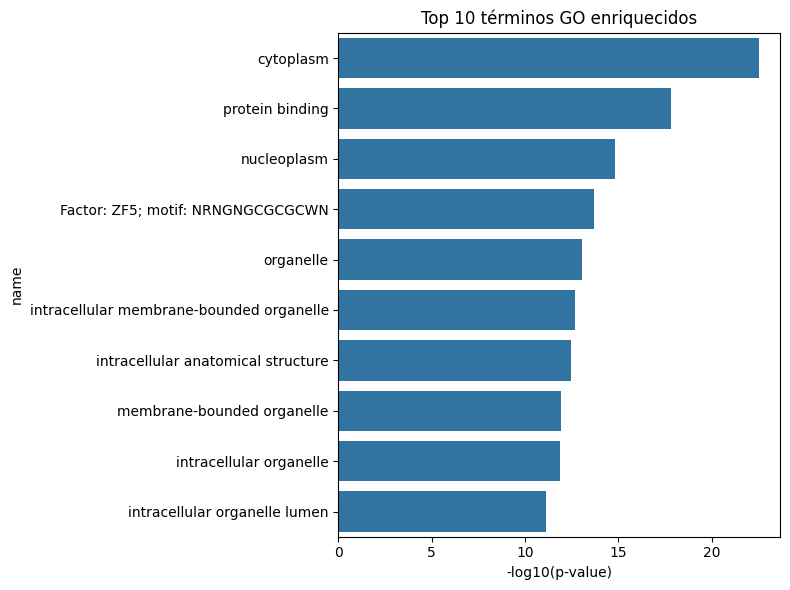

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = results.sort_values('p_value').head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=-np.log10(top10['p_value']), y=top10['name'])
plt.xlabel('-log10(p-value)')
plt.title('Top 10 términos GO enriquecidos')
plt.tight_layout()
plt.show()
